In [12]:
import pathlib
import random
import numpy as np
from qiskit import QuantumCircuit, transpile
import seaborn as sns
from qiskit.transpiler.passes import ApplyLayout

from contrib.common import read_json, read_mapping
from hamap.mapping import ha_mapping
from hamap import IBMQHardwareArchitecture
from contrib.random_graphs import create_coupling_graph
from qiskit.quantum_info import DensityMatrix, Statevector
from typing import Union
from qiskit.transpiler.passmanager import PassManager

import networkx as nx
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Instruction, CircuitInstruction
from qiskit.quantum_info import Statevector
from qiskit.transpiler import CouplingMap, TranspileLayout


In [28]:
qc_in = QuantumCircuit.from_qasm_file('output/mod_mult_55.qasm-star/input_circuit.qasm')
qc_out = QuantumCircuit.from_qasm_file('output/mod_mult_55.qasm-star/output_circuit.qasm')
initial_mapping = read_mapping('output/mod_mult_55.qasm-star/initial_mapping.json')
# final_mapping = read_mapping('./output/nam_circs/mod_mult_55.qams-star/final_mapping.json')

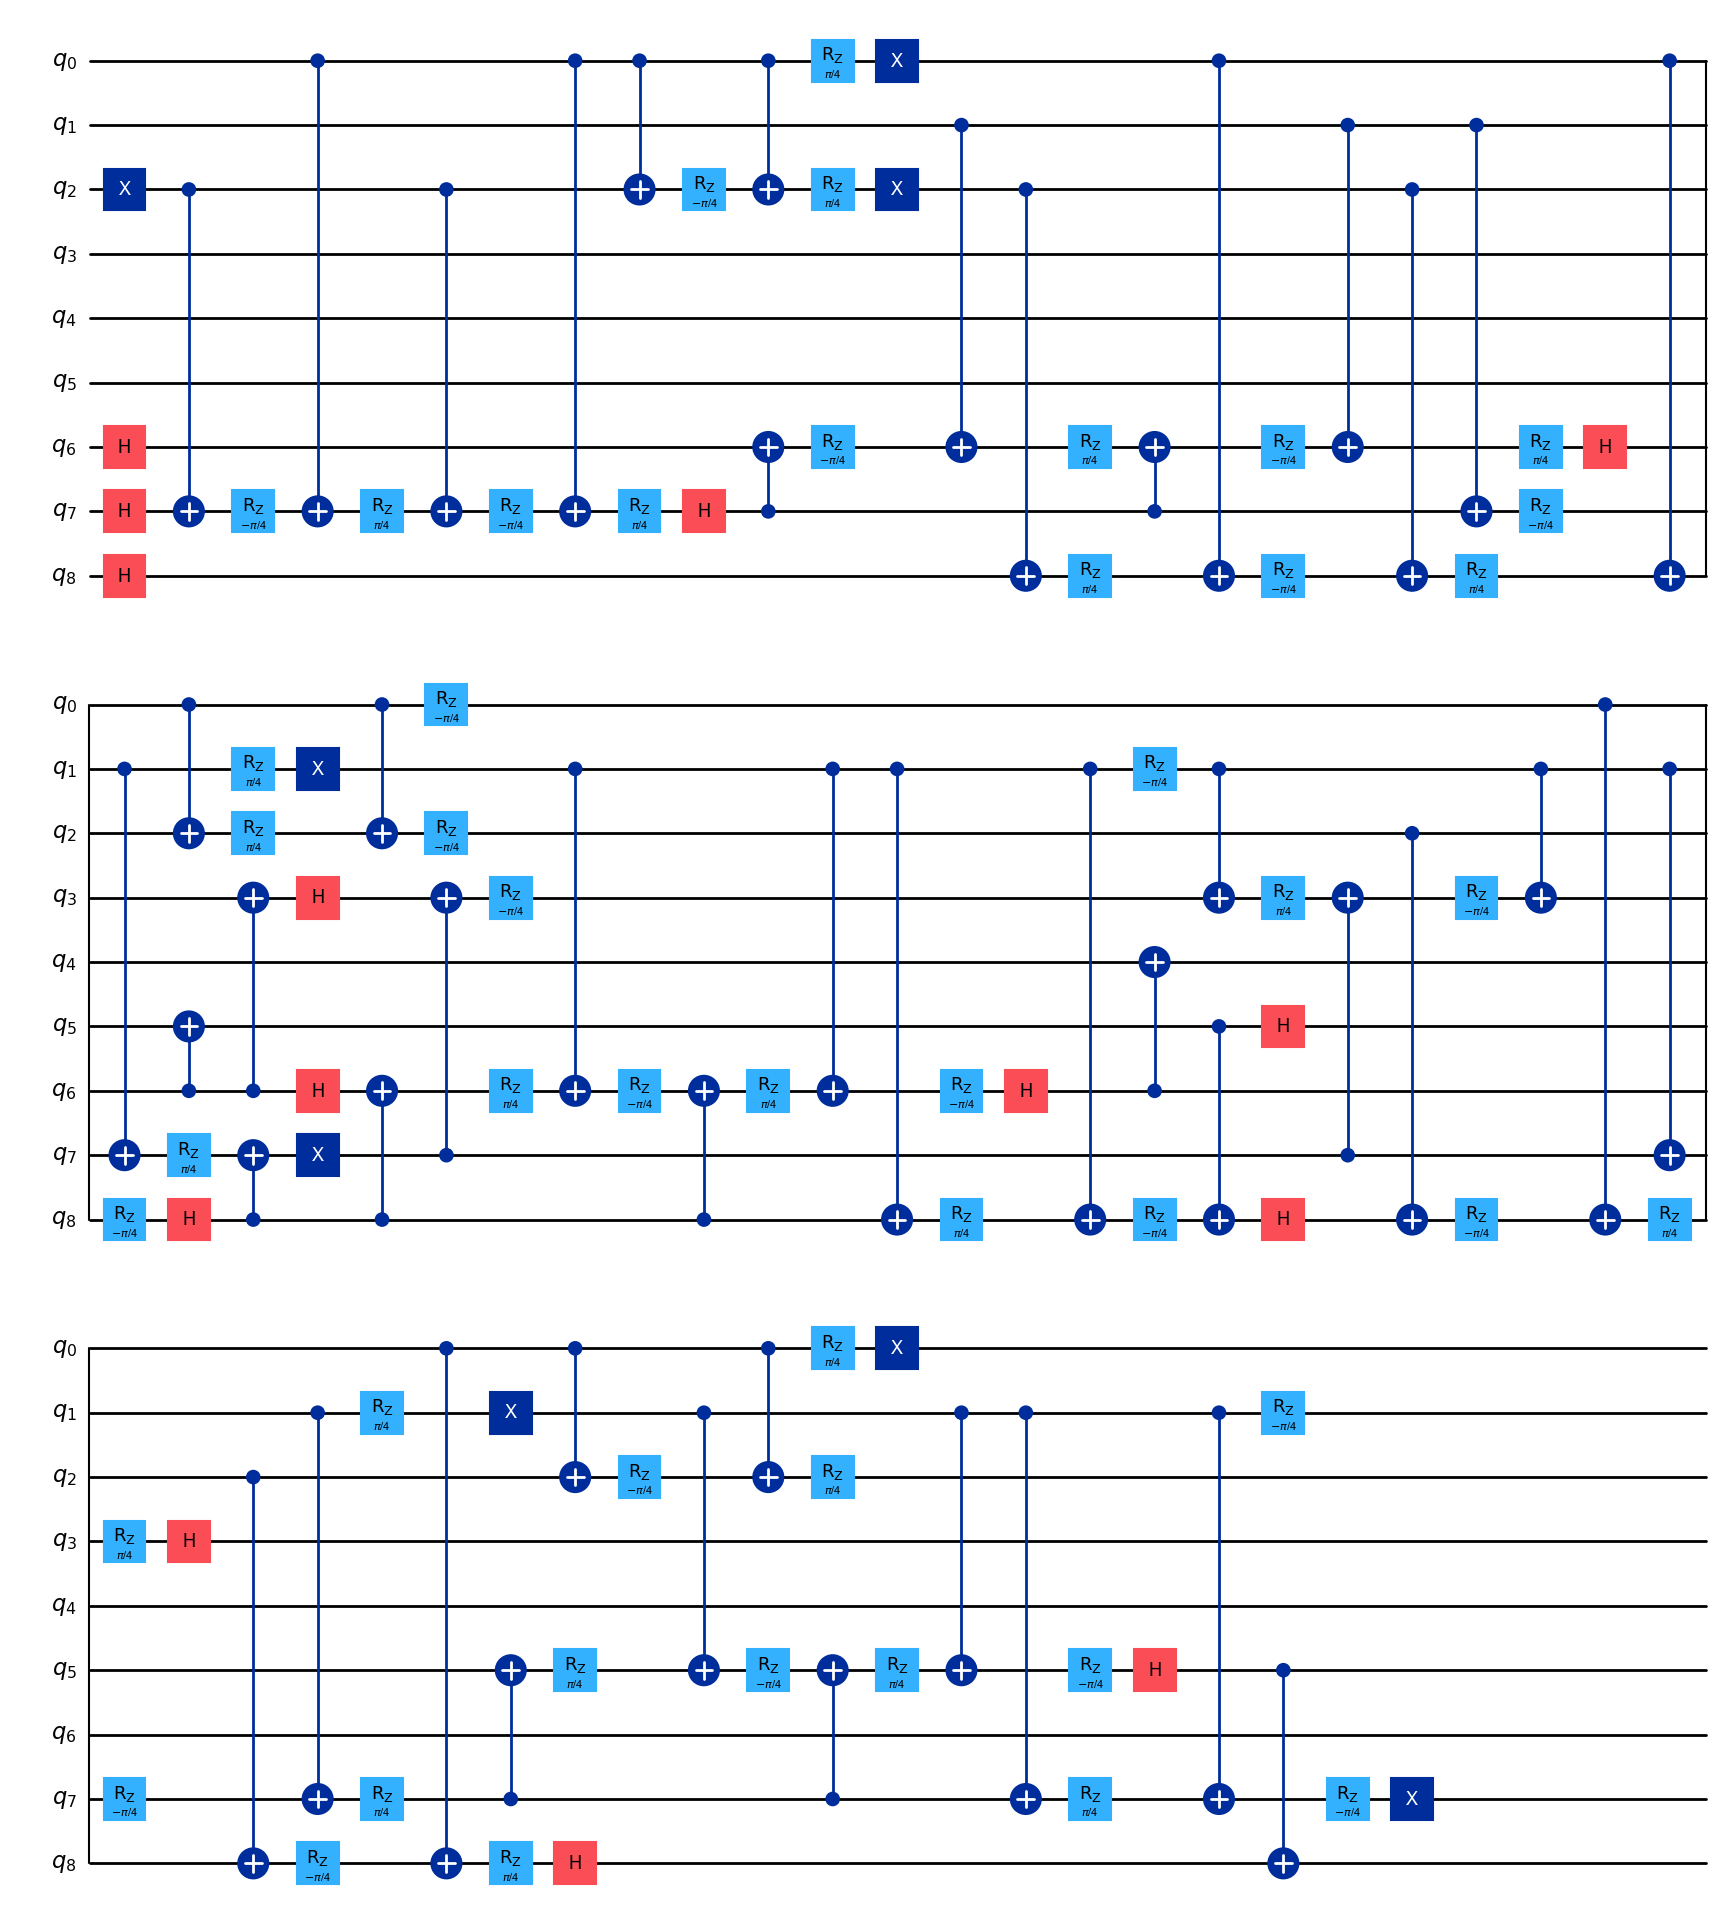

In [36]:
qc_in.draw('mpl')

In [38]:
from qiskit.transpiler import Layout
from qiskit import QuantumRegister

vreg = QuantumRegister(len(initial_mapping), name='q')
initial_layout = Layout({vreg[v]: p for v, p in initial_mapping.items()})


In [39]:
initial_layout, initial_mapping

(Layout({
 6: <Qubit register=(9, "q"), index=0>,
 3: <Qubit register=(9, "q"), index=1>,
 7: <Qubit register=(9, "q"), index=2>,
 2: <Qubit register=(9, "q"), index=3>,
 1: <Qubit register=(9, "q"), index=4>,
 4: <Qubit register=(9, "q"), index=5>,
 5: <Qubit register=(9, "q"), index=6>,
 0: <Qubit register=(9, "q"), index=7>,
 8: <Qubit register=(9, "q"), index=8>
 }),
 {0: 6, 1: 3, 2: 7, 3: 2, 4: 1, 5: 4, 6: 5, 7: 0, 8: 8})

In [6]:
from qiskit.transpiler.passes import SetLayout

pm = PassManager([SetLayout(initial_layout),
                  ApplyLayout()])
qc_mapped = pm.run(qc_in)

In [9]:
Statevector(qc_mapped).equiv(Statevector(qc_out))

True

In [22]:
def check_equivalence_under_mapping(qc_in, qc_out, initial_mapping):
    if isinstance(initial_mapping, Layout):
        initial_layout = initial_mapping
    else:
        vreg = QuantumRegister(len(initial_mapping), name='q')
        initial_layout = Layout({vreg[v]: p for v, p in initial_mapping.items()})

    pm = PassManager([SetLayout(initial_layout), ApplyLayout()])
    qc_mapped = pm.run(qc_in)
    return Statevector(qc_mapped).equiv(Statevector(qc_out))


In [31]:
check_equivalence_under_mapping(qc_in, qc_out, initial_mapping)

True

In [18]:
def check_output():
    for subdir in pathlib.Path('./output').iterdir():

        qc_in = QuantumCircuit.from_qasm_file(subdir / 'input_circuit.qasm')
        qc_out = QuantumCircuit.from_qasm_file(subdir / 'output_circuit.qasm')
        initial_mapping = read_mapping(subdir / 'initial_mapping.json')
        final_mapping = read_mapping(subdir / 'final_mapping.json')
        config = read_json(subdir/ 'config.json')
        if config['qubit_number'] > 10:
            print('skip', subdir.name, config['qubit_number'])
            continue
        ok = check_equivalence_under_mapping(qc_in, qc_out, initial_mapping)
        # print(subdir.name, ok)
        assert ok

In [40]:
qc_out2=transpile(qc_in, coupling_map=CouplingMap.from_line(qc_in.num_qubits), initial_layout=initial_layout)

In [41]:
check_equivalence_under_mapping(qc_in, qc_out2, qc_out2.layout.initial_layout)

True

In [42]:
qc_out2.layout.initial_layout

Layout({
6: <Qubit register=(9, "q"), index=0>,
3: <Qubit register=(9, "q"), index=1>,
7: <Qubit register=(9, "q"), index=2>,
2: <Qubit register=(9, "q"), index=3>,
1: <Qubit register=(9, "q"), index=4>,
4: <Qubit register=(9, "q"), index=5>,
5: <Qubit register=(9, "q"), index=6>,
0: <Qubit register=(9, "q"), index=7>,
8: <Qubit register=(9, "q"), index=8>
})

In [43]:
initial_layout

Layout({
6: <Qubit register=(9, "q"), index=0>,
3: <Qubit register=(9, "q"), index=1>,
7: <Qubit register=(9, "q"), index=2>,
2: <Qubit register=(9, "q"), index=3>,
1: <Qubit register=(9, "q"), index=4>,
4: <Qubit register=(9, "q"), index=5>,
5: <Qubit register=(9, "q"), index=6>,
0: <Qubit register=(9, "q"), index=7>,
8: <Qubit register=(9, "q"), index=8>
})

In [44]:
initial_layout.get_virtual_bits()

{<Qubit register=(9, "q"), index=0>: 6,
 <Qubit register=(9, "q"), index=1>: 3,
 <Qubit register=(9, "q"), index=2>: 7,
 <Qubit register=(9, "q"), index=3>: 2,
 <Qubit register=(9, "q"), index=4>: 1,
 <Qubit register=(9, "q"), index=5>: 4,
 <Qubit register=(9, "q"), index=6>: 5,
 <Qubit register=(9, "q"), index=7>: 0,
 <Qubit register=(9, "q"), index=8>: 8}

In [45]:
initial_layout.get_physical_bits()

{6: <Qubit register=(9, "q"), index=0>,
 3: <Qubit register=(9, "q"), index=1>,
 7: <Qubit register=(9, "q"), index=2>,
 2: <Qubit register=(9, "q"), index=3>,
 1: <Qubit register=(9, "q"), index=4>,
 4: <Qubit register=(9, "q"), index=5>,
 5: <Qubit register=(9, "q"), index=6>,
 0: <Qubit register=(9, "q"), index=7>,
 8: <Qubit register=(9, "q"), index=8>}

In [75]:
qc_in = QuantumCircuit.from_qasm_file('./input.qasm')
qc_out = QuantumCircuit.from_qasm_file(('./output.qasm'))
initial_mapping = read_mapping('./initial_mapping.json')

In [67]:
initial_mapping

{0: 4, 1: 2, 2: 6, 3: 0, 4: 8, 5: 1, 6: 3, 7: 5, 8: 7}

In [68]:
from qiskit.transpiler.passes import SetLayout

vreg = QuantumRegister(len(initial_mapping), name='q')
initial_layout = Layout({vreg[v]: p for v, p in initial_mapping.items()})

pm = PassManager([SetLayout(initial_layout),
                  ApplyLayout()])
qc_mapped = pm.run(qc_in)

In [69]:
check_equivalence_under_mapping(qc_in, qc_mapped, initial_mapping)

True

In [70]:
initial_mapping

{0: 4, 1: 2, 2: 6, 3: 0, 4: 8, 5: 1, 6: 3, 7: 5, 8: 7}